In [1]:
from dhlab.api.dhlab_api import get_document_frequencies
from dhlab import Corpus, Counts, totals
from dhlab import nbtext as nb

In [2]:
bøker = Corpus(
   doctype="digibok",
   freetext="krig OR krigen OR soldater",
   from_year=1950,
   to_year=2010,
   ddk="9*",
   lang='nob',
   limit=30
)

In [3]:
bøker.frame.loc[:, ["title", "authors", "year"]]

,title,authors,year
0,"Nikkel , jern og blod : krigen i nord 1939-1945","Jacobsen , Alf R. / Skjold , Erling / Rautio ,...",2007
1,Nøtterøys historie : 1900-tallet . 1 : Nøtterø...,"Christophersen , Egil",2009
2,""" Vaktvern i krig "" : Sør-Helgeland 1940","Åsvang , Arnt O.",1978
3,Det hendte meg en krig,"Norvalls , Tuppen / Hansen , Olav Herman .",1987
4,Hellig krig : Osama bin Ladens hemmelige nettverk,"Bergen , Peter L. / Stefansen , Arnt",2002
5,Snikskytter på Østfronten,"Wacker , Albrecht / Ødegaard , Roger",2009
6,Krigen i det tidligere Jugoslavia,"Harris , Nathaniel / Thorsteinsen , Tom",2001
7,Norge i krig : [ bokmål ],"Henriksen , Jan O. / Henriksen , Jan Oddvar",1982
8,"Nikkel , jern og blod : krigen i nord 1939-1945","Jacobsen , Alf R. / Rautio , Rune / Skjold , E...",2006
9,I Tordenskiolds kjølvann,"Kavli , Guthorm",1990


In [4]:
# tar de fem første og henter frekvensene for alle bøkene

bøker_dtm = Counts(bøker.head(5))

In [5]:
bøker_dtm 

,100102094,100153414,100494689,100207265,100232832
",",3184,791,13772,4418,8775
.,2988,980,11576,4863,5076
og,1791,592,6635,3535,2409
i,1097,433,6740,2994,3503
det,955,321,3869,1125,1043
...,...,...,...,...,...
aksjeindeksen,0,0,0,0,1
ødemark,0,0,0,2,0
FRA,0,0,0,4,12
Qaida,0,0,0,0,5


In [6]:
nb.heatmap(bøker_dtm.frame.head(10), color="#045599")

,100102094,100153414,100494689,100207265,100232832
",",3184,791,13772,4418,8775
.,2988,980,11576,4863,5076
og,1791,592,6635,3535,2409
i,1097,433,6740,2994,3503
det,955,321,3869,1125,1043
var,948,485,4280,1669,1273
»,778,80,5,1188,919
«,777,76,10,1187,945
jeg,774,7,132,304,282
på,703,347,4004,1006,1222


In [7]:
count_corpus = Counts(bøker)

In [8]:
totals = totals(150000)

In [9]:
# Summer tokens fra korpus
bøker_total = count_corpus.frame.sum(1).to_frame("count")

In [10]:
# Frekvensliste for korpus
bøker_total

,count
.,145356
",",140725
i,69235
og,72725
var,38399
...,...
tout,3
Saint-Huillier,4
Moldova,3
DDR-44,1


In [11]:
nb.normalize_corpus_dataframe(totals)
nb.normalize_corpus_dataframe(bøker_total)

True

In [12]:
forskjell = bøker_total.loc[:, "count"] / totals.freq

In [13]:
bøker_typiske_ord = forskjell.sort_values(ascending=False).to_frame("ratio")

In [14]:
bøker_typiske_ord.head(50)

,ratio
Sepp,469.689866
BLOD,332.920714
Førerens,250.438495
Tordenskiold,250.279982
skp,217.756689
Laden,217.234201
Petsamo,215.339272
fremrakende,194.119097
N.D,192.461535
Ciano,191.109322


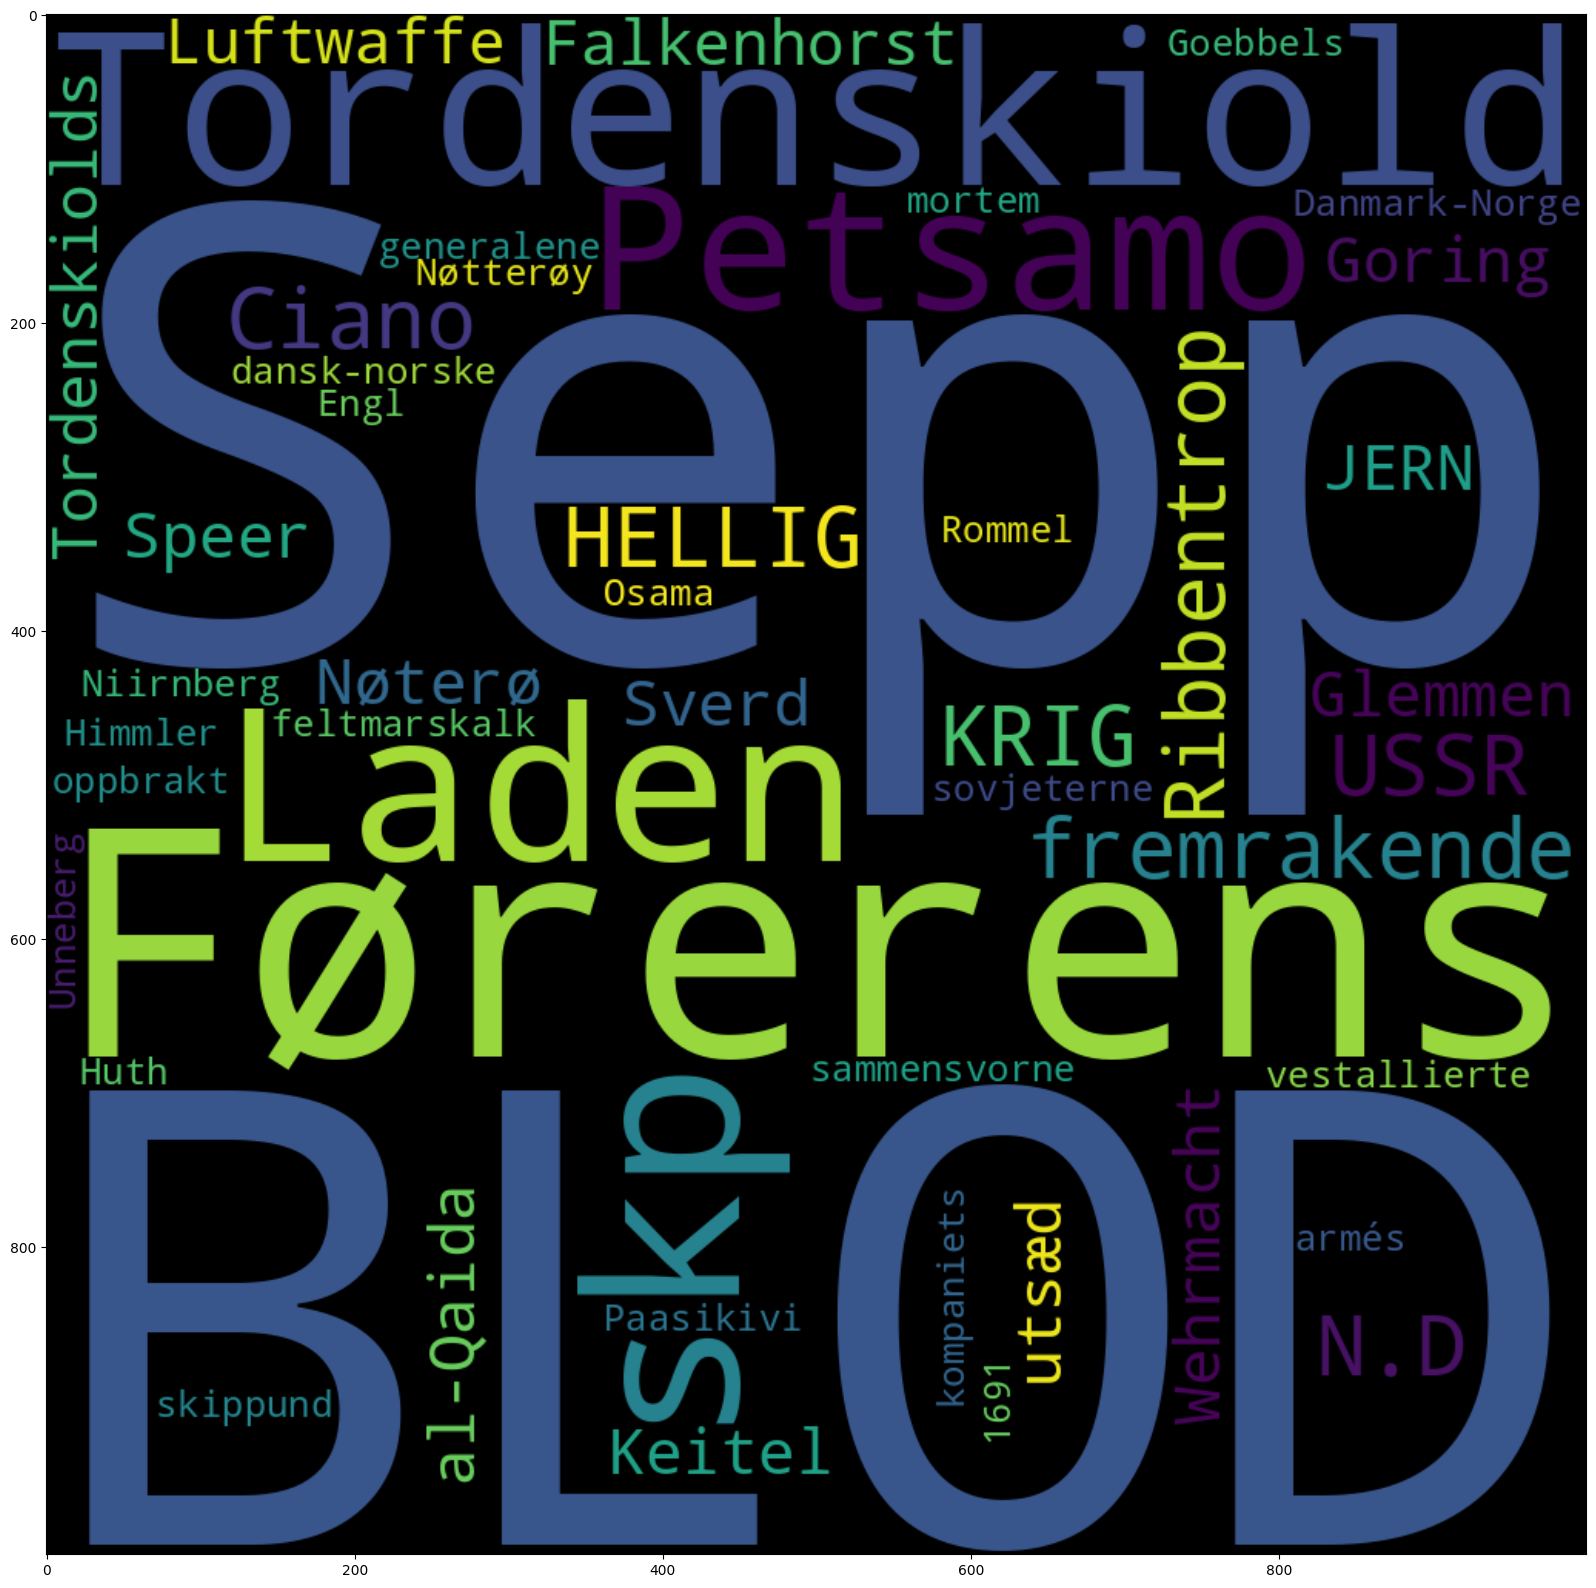

In [15]:
nb.cloud((bøker_typiske_ord/bøker_typiske_ord.sum()).head(50))